
===== Year 2013-2014 =====
Number of nodes: 1869
Number of edges: 13059

Top 10 nodes by degree:
google.com: 358
pagead2.googlesyndication.com: 344
googlesyndication.com: 334
apis.google.com: 252
stats.wordpress.com: 251
www.google.com: 246
twitter.com: 234
platform.twitter.com: 231
ajax.googleapis.com: 228
www.facebook.com: 228

=== Freeman Degree Centralization ===
Max degree (d_max): 358
Sum of differences (Σ(d_max - d_i)): 642984
Centralization value: 0.1844

===== Year 2014-2015 =====
Number of nodes: 1893
Number of edges: 12419

Top 10 nodes by degree:
google.com: 369
pagead2.googlesyndication.com: 322
ajax.googleapis.com: 287
googlesyndication.com: 286
googleapis.com: 267
apis.google.com: 257
www.google.com: 241
stats.wordpress.com: 224
platform.twitter.com: 218
twitter.com: 212

=== Freeman Degree Centralization ===
Max degree (d_max): 369
Sum of differences (Σ(d_max - d_i)): 673679
Centralization value: 0.1883

===== Year 2015-2016 =====
Number of nodes: 1816
Number of edges:

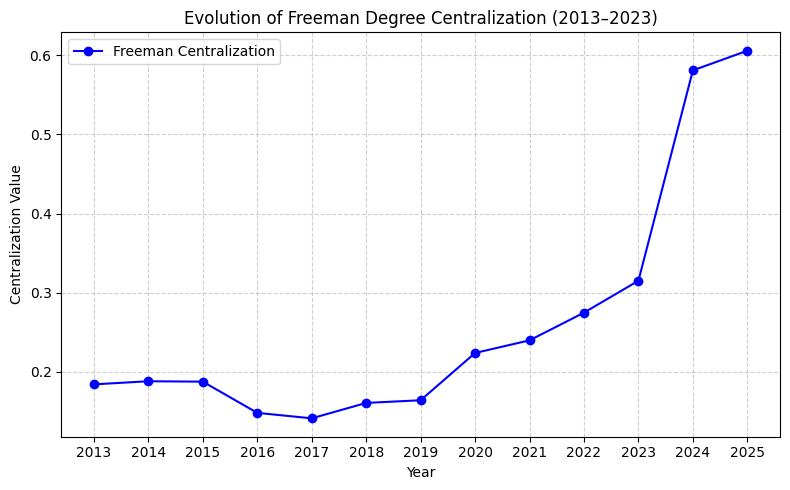

Centralization trend plot saved to: /content/freeman_centralization_trend.png


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

def freeman_degree_centralization(G):
    degree_dict = dict(G.degree())
    n = len(degree_dict)
    if n <= 2:
        return None, None, None
    d_max = max(degree_dict.values())
    sum_diff = sum(d_max - d for d in degree_dict.values())
    centralization = sum_diff / ((n - 1) * (n - 2))
    return d_max, sum_diff, centralization


results = []
for start_year in range(2013, 2026):
    end_year = start_year + 1
    file_name = f"graph_{start_year}_{end_year}.gpickle"
    file_path = os.path.join("/content", file_name)
    if not os.path.exists(file_path):
        print(f"File not found: {file_name}")
        continue

    with open(file_path, "rb") as f:
        G = pickle.load(f)

    print(f"\n===== Year {start_year}-{end_year} =====")
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())

    # --- Degree centrality ---
    degree_dict = dict(G.degree())
    top10 = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\nTop 10 nodes by degree:")
    for node, deg in top10:
        print(f"{node}: {deg}")

    # --- Freeman Degree Centralization ---
    d_max, sum_diff, centralization = freeman_degree_centralization(G)
    if centralization is not None:
        print("\n=== Freeman Degree Centralization ===")
        print(f"Max degree (d_max): {d_max}")
        print(f"Sum of differences (Σ(d_max - d_i)): {sum_diff}")
        print(f"Centralization value: {centralization:.4f}")
    else:
        print("Graph too small to compute centralization.")

    # Save result for CSV
    results.append({
        "year": f"{start_year}",
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "d_max": d_max,
        "sum_diff": sum_diff,
        "centralization": centralization
    })

# === Save all results to CSV (in Colab) ===
df_results = pd.DataFrame(results)
out_path = "/content/freeman_centralization_summary.csv"
df_results.to_csv(out_path, index=False)

print("\nSaved results to:", out_path)
print(df_results)

# === Plot Centralization Trend (saved in Colab) ===
plt.figure(figsize=(8, 5))
plt.plot(df_results["year"], df_results["centralization"], marker="o", color="blue", label="Freeman Centralization")
plt.xticks()
plt.xlabel("Year")
plt.ylabel("Centralization Value")
plt.title("Evolution of Freeman Degree Centralization (2013–2023)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Save plot in /content
plot_path = "/content/freeman_centralization_trend.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print("Centralization trend plot saved to:", plot_path)


In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))

# Bars with hatch design (wider to reduce gaps)
plt.bar(df_results["year"], df_results["centralization"],
        width=0.75, color="orange", edgecolor="black", linewidth=1, hatch='.', alpha=1)

# Line overlay
plt.plot(df_results["year"], df_results["centralization"],
         marker="o", markersize=15, color="#32CD32", linewidth=5, zorder=3)

# Labels
plt.ylabel("Centralization Value", fontsize=32)
plt.xticks(fontsize=32,rotation=45)
plt.yticks(fontsize=32)

# Remove gaps on x-axis
plt.xlim(-0.5, len(df_results["year"]) - 0.5)

# Remove plot frame (spines)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()

# Save high-quality image
plot_path = "/content/freeman_centralization_trend.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()
print("✅ High-quality image saved at:", plot_path)


NameError: name 'df_results' is not defined

<Figure size 2000x1200 with 0 Axes>